# SVM : marge maximale et kernel trick

Un SVM (*Support Vector Machine*) cherche, parmi tous les hyperplans qui séparent deux classes, celui qui laisse le plus d'espace possible de chaque côté. Ce notebook part de cette idée et construit, formule par formule, le mécanisme complet : la position exacte de l'hyperplan de marge maximale, puis le kernel trick, qui permet de séparer des données qui ne le sont pas linéairement sans jamais calculer explicitement leur transformation vers un espace de dimension supérieure.

**Ce que ce notebook construit :**
1. La résolution du problème d'optimisation exact du SVM sur un exemple minimal, en résolvant nous-mêmes le problème de minimisation sous contraintes — sans passer par une bibliothèque de machine learning.
2. Une vérification, également from scratch, de l'identité mathématique qui fonde le kernel trick.
3. Une comparaison contre `scikit-learn`, pour confirmer que les deux approches convergent vers le même résultat.
4. Une application à un cas de détection de fraude où les deux classes ne sont pas linéairement séparables, avec noyau RBF.
5. Une étude de l'effet de deux hyperparamètres clés, `gamma` et `C`, sur le sur-apprentissage.

**Public visé :** lecteurs à l'aise avec Python et les bases de l'algèbre linéaire, mais pas nécessairement familiers des SVM.

**Prérequis :** `numpy`, `scipy`, `scikit-learn`, `matplotlib`.

**Plan :** données → mécanisme sur un exemple minimal → implémentation from scratch → validation contre scikit-learn → application à un cas de fraude → effet des hyperparamètres → ce que la démo établit → références.

*Reproductibilité : Python 3.12, numpy 2.4, scipy 1.17, scikit-learn 1.8, matplotlib 3.10. Toutes les graines aléatoires sont fixées à 42.*

## 1. Les données

Le cas d'usage retenu est un scénario de détection de fraude : chaque transaction est décrite par deux variables comportementales standardisées (montant et fréquence des transactions récentes), et l'objectif est de séparer les transactions frauduleuses des transactions légitimes. Les deux classes forment ici des groupes en forme de croissants entrelacés — un motif non linéaire couramment observé quand une fraude combine deux facteurs de façon conjointe plutôt qu'indépendante. Le jeu de données est généré de façon synthétique et reproductible, pour que ce notebook s'exécute de façon autonome.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.svm import SVC
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Jeu de donnees synthetique : deux classes non lineairement separables,
# reetiquetees pour representer un cas de detection de fraude
X_fraude, y_fraude = make_moons(n_samples=400, noise=0.15, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X_fraude, y_fraude, test_size=0.25, random_state=RANDOM_STATE, stratify=y_fraude
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Jeu d'entrainement : {X_train_s.shape[0]} transactions, {X_train_s.shape[1]} variables")
print(f"Jeu de test : {X_test_s.shape[0]} transactions")
print(f"Proportion de fraude (entrainement) : {y_train.mean():.2%}")
print("\nAperçu des 5 premières lignes standardisées (montant, frequence) et de leur etiquette :")
for row, label in list(zip(X_train_s, y_train))[:5]:
    print(f"  montant={row[0]:+.2f}  frequence={row[1]:+.2f}  ->  {'fraude' if label == 1 else 'legitime'}")

Jeu d'entrainement : 300 transactions, 2 variables
Jeu de test : 100 transactions
Proportion de fraude (entrainement) : 50.00%

Aperçu des 5 premières lignes standardisées (montant, frequence) et de leur etiquette :
  montant=-0.86  frequence=+0.61  ->  fraude
  montant=-0.72  frequence=+1.37  ->  legitime
  montant=-1.67  frequence=+0.70  ->  legitime
  montant=+0.73  frequence=-1.22  ->  fraude
  montant=-1.42  frequence=+1.50  ->  legitime


## 2. Le mécanisme sur un exemple minimal

Avant d'aborder le cas de fraude complet, on travaille sur quatre points seulement, pour rendre chaque quantité tangible. Deux points, `(3,4)` pour la classe positive et `(1,1)` pour la classe négative, sont volontairement placés comme vecteurs de support : ce sont eux qui vont fixer la position de l'hyperplan. Les deux autres, `(4,5)` et `(0,0)`, sont plus loin de la frontière et ne devraient avoir aucune influence sur le résultat.

Pour un hyperplan `w·x + b = 0`, la distance d'un point `x` à cet hyperplan vaut `(w·x + b) / ||w||`. Pour les vecteurs de support, cette distance normalisée vaut exactement `1 / ||w||` de chaque côté, ce qui donne une marge totale de `2 / ||w||`. On calcule ici ces quantités à la main, pour un couple `(w, b)` choisi arbitrairement, avant toute optimisation.

In [2]:
# Les 4 points de l'exemple minimal
X_toy = np.array([[3, 4], [4, 5], [1, 1], [0, 0]], dtype=float)
y_toy = np.array([1.0, 1.0, -1.0, -1.0])

# Un couple (w, b) choisi a la main, oriente dans la bonne direction mais pas encore optimal
w_essai = np.array([2.0, 3.0])
b_essai = -11.5

print("Distance de chaque point a l'hyperplan d'essai (w.x + b) / ||w|| :")
for point, label in zip(X_toy, y_toy):
    distance = (w_essai @ point + b_essai) / np.linalg.norm(w_essai)
    cote = "positif" if label == 1 else "negatif"
    print(f"  point={point}, classe {cote} -> distance = {distance:+.4f}")

marge_essai = 2 / np.linalg.norm(w_essai)
print(f"\nMarge associee a cet essai : 2 / ||w|| = {marge_essai:.4f}")
print("Cette marge n'a aucune raison d'etre optimale : w et b ont ete choisis a la main.")
print("La section suivante resout le probleme d'optimisation qui donne le (w, b) optimal.")

Distance de chaque point a l'hyperplan d'essai (w.x + b) / ||w|| :
  point=[3. 4.], classe positif -> distance = +1.8028
  point=[4. 5.], classe positif -> distance = +3.1895
  point=[1. 1.], classe negatif -> distance = -1.8028
  point=[0. 0.], classe negatif -> distance = -3.1895

Marge associee a cet essai : 2 / ||w|| = 0.5547
Cette marge n'a aucune raison d'etre optimale : w et b ont ete choisis a la main.
La section suivante resout le probleme d'optimisation qui donne le (w, b) optimal.


## 3. Implémentation from scratch

### 3.1 Le problème d'optimisation exact du SVM

Le SVM à marge dure résout : minimiser `0.5 * ||w||^2` sous la contrainte `y_i (w·x_i + b) >= 1` pour chaque point `i`. C'est un problème d'optimisation convexe sous contraintes — on le résout ici directement avec un solveur numérique générique (`scipy.optimize.minimize`, méthode SLSQP), en lui donnant explicitement la fonction à minimiser, son gradient, et chacune des contraintes. Aucune bibliothèque de machine learning n'intervient à ce stade : c'est la formulation mathématique du problème, telle quelle, qui produit le résultat.

In [3]:
class SVMLineaireMargeDure:
    """SVM lineaire a marge dure, resolu en formulant explicitement
    le probleme d'optimisation convexe minimiser 0.5*||w||^2
    sous contrainte y_i (w.x_i + b) >= 1 pour chaque point i.

    Attributs apres fit() :
        w_ : vecteur de poids (orientation de l'hyperplan)
        b_ : biais (decalage de l'hyperplan)
    """

    def fit(self, X, y):
        n_samples, n_features = X.shape

        def objectif(params):
            w = params[:n_features]
            return 0.5 * np.dot(w, w)

        def gradient_objectif(params):
            w = params[:n_features]
            return np.concatenate([w, [0.0]])

        # une contrainte d'inegalite par point : y_i (w.x_i + b) - 1 >= 0
        contraintes = []
        for xi, yi in zip(X, y):
            def contrainte(params, xi=xi, yi=yi):
                w, b = params[:n_features], params[-1]
                return yi * (xi @ w + b) - 1

            def jacobienne(params, xi=xi, yi=yi):
                jac = np.zeros(n_features + 1)
                jac[:n_features] = yi * xi
                jac[-1] = yi
                return jac

            contraintes.append({"type": "ineq", "fun": contrainte, "jac": jacobienne})

        params0 = np.zeros(n_features + 1)
        resultat = minimize(
            objectif, params0, jac=gradient_objectif,
            constraints=contraintes, method="SLSQP",
            options={"maxiter": 1000, "ftol": 1e-12},
        )
        if not resultat.success:
            raise RuntimeError(f"L'optimisation n'a pas converge : {resultat.message}")

        self.w_ = resultat.x[:n_features]
        self.b_ = resultat.x[-1]
        return self

    def marge(self):
        """Largeur de la marge : 2 / ||w||."""
        return 2 / np.linalg.norm(self.w_)


svm_scratch = SVMLineaireMargeDure().fit(X_toy, y_toy)
print(f"w = {svm_scratch.w_}")
print(f"b = {svm_scratch.b_:.4f}")
print(f"marge = 2/||w|| = {svm_scratch.marge():.4f}")

print("\nVerification y_i (w.x_i + b) pour chaque point :")
for xi, yi in zip(X_toy, y_toy):
    valeur = yi * (svm_scratch.w_ @ xi + svm_scratch.b_)
    print(f"  point={xi}, y={yi:+.0f} -> {valeur:.4f}")

w = [0.30769231 0.46153846]
b = -1.7692
marge = 2/||w|| = 3.6056

Verification y_i (w.x_i + b) pour chaque point :
  point=[3. 4.], y=+1 -> 1.0000
  point=[4. 5.], y=+1 -> 1.7692
  point=[1. 1.], y=-1 -> 1.0000
  point=[0. 0.], y=-1 -> 1.7692


### 3.2 Le kernel trick : vérifier l'identité sans jamais calculer la transformation

La formulation duale du SVM ne fait intervenir les points qu'à travers un produit scalaire `x_i · x_j`. Conséquence : pour travailler dans un espace transformé par une fonction `φ`, il suffit de remplacer ce produit scalaire par `φ(x_i) · φ(x_j)` — sans jamais calculer `φ` explicitement, à condition de disposer d'une fonction noyau `K` qui donne directement ce résultat. On le vérifie ici sur la transformation `φ(x1, x2) = (x1², √2·x1·x2, x2²)`, dont le noyau associé est `K(a, b) = (a·b)²`.

In [4]:
def phi(x):
    """Transformation explicite vers un espace de dimension 3."""
    x1, x2 = x
    return np.array([x1**2, np.sqrt(2) * x1 * x2, x2**2])

def noyau_polynomial_degre2(u, v):
    """Noyau K(u,v) = (u.v)^2, calcule sans jamais passer par phi."""
    return (u @ v) ** 2

a = np.array([1, 2])
b_point = np.array([3, 1])

# methode 1 : transformation explicite puis produit scalaire
produit_explicite = phi(a) @ phi(b_point)

# methode 2 : noyau direct, sans jamais calculer phi
produit_noyau = noyau_polynomial_degre2(a, b_point)

print(f"phi(a) = {phi(a)}")
print(f"phi(b) = {phi(b_point)}")
print(f"phi(a) . phi(b), calcul explicite : {produit_explicite:.4f}")
print(f"K(a,b) = (a.b)^2, calcul par le noyau : {produit_noyau}")

assert np.isclose(produit_explicite, produit_noyau)
print("\nLes deux calculs coincident : le noyau donne le meme resultat que la transformation")
print("explicite, sans jamais avoir eu besoin de calculer phi.")

phi(a) = [1.         2.82842712 4.        ]
phi(b) = [9.         4.24264069 1.        ]
phi(a) . phi(b), calcul explicite : 25.0000
K(a,b) = (a.b)^2, calcul par le noyau : 25

Les deux calculs coincident : le noyau donne le meme resultat que la transformation
explicite, sans jamais avoir eu besoin de calculer phi.


## 4. Validation

On confronte la solution obtenue par résolution directe du problème d'optimisation à celle que produit `scikit-learn` sur les mêmes quatre points, avec un `C` très élevé pour imposer une marge dure équivalente.

In [5]:
svm_sklearn = SVC(kernel="linear", C=1e6).fit(X_toy, y_toy)
w_sklearn = svm_sklearn.coef_[0]
b_sklearn = svm_sklearn.intercept_[0]

print(f"{'':20s}{'from scratch':>18s}{'scikit-learn':>18s}{'ecart absolu':>16s}")
for i in range(len(svm_scratch.w_)):
    ecart = abs(svm_scratch.w_[i] - w_sklearn[i])
    print(f"{'w[' + str(i) + ']':20s}{svm_scratch.w_[i]:18.4f}{w_sklearn[i]:18.4f}{ecart:16.2e}")
ecart_b = abs(svm_scratch.b_ - b_sklearn)
print(f"{'b':20s}{svm_scratch.b_:18.4f}{b_sklearn:18.4f}{ecart_b:16.2e}")

marge_sklearn = 2 / np.linalg.norm(w_sklearn)
print(f"\nMarge from scratch : {svm_scratch.marge():.4f}")
print(f"Marge scikit-learn : {marge_sklearn:.4f}")

assert np.allclose(svm_scratch.w_, w_sklearn, atol=1e-3)
assert np.isclose(svm_scratch.b_, b_sklearn, atol=1e-3)
print("\nLes deux resolutions convergent vers le meme hyperplan a la tolerance numerique pres.")
print(f"Vecteurs de support identifies par scikit-learn : {X_toy[svm_sklearn.support_].tolist()}")

                          from scratch      scikit-learn    ecart absolu
w[0]                            0.3077            0.3077        5.55e-17
w[1]                            0.4615            0.4615        5.55e-17
b                              -1.7692           -1.7692        2.22e-16

Marge from scratch : 3.6056
Marge scikit-learn : 3.6056

Les deux resolutions convergent vers le meme hyperplan a la tolerance numerique pres.
Vecteurs de support identifies par scikit-learn : [[1.0, 1.0], [3.0, 4.0]]


## 5. Application au cas de détection de fraude

Sur le jeu de données complet, la résolution directe de la section 3 n'est plus praticable telle quelle : les classes ne sont pas linéairement séparables, et le kernel trick nécessite de résoudre la formulation duale avec une matrice de similarités entre toutes les paires de points — un calcul que `scikit-learn` réalise en interne de façon optimisée. On l'utilise donc ici directement pour entraîner deux modèles, un noyau linéaire et un noyau RBF, et on compare leur capacité à séparer les deux classes de transactions.

In [6]:
svm_lineaire = SVC(kernel="linear", C=1.0).fit(X_train_s, y_train)
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale").fit(X_train_s, y_train)

for nom, modele in [("lineaire", svm_lineaire), ("RBF", svm_rbf)]:
    predictions = modele.predict(X_test_s)
    accuracy = accuracy_score(y_test, predictions)
    matrice = confusion_matrix(y_test, predictions)
    faux_negatifs = matrice[1, 0]  # fraude predite comme legitime
    print(f"Noyau {nom:8s} | accuracy test = {accuracy:.3f} | "
          f"fraudes manquees = {faux_negatifs}/{matrice[1].sum()} | "
          f"vecteurs de support = {len(modele.support_)}")

Noyau lineaire | accuracy test = 0.920 | fraudes manquees = 4/50 | vecteurs de support = 107
Noyau RBF      | accuracy test = 0.980 | fraudes manquees = 1/50 | vecteurs de support = 65


La figure suivante montre la frontière de décision des deux modèles sur les données d'entraînement, ainsi que leur accuracy sur le jeu de test.

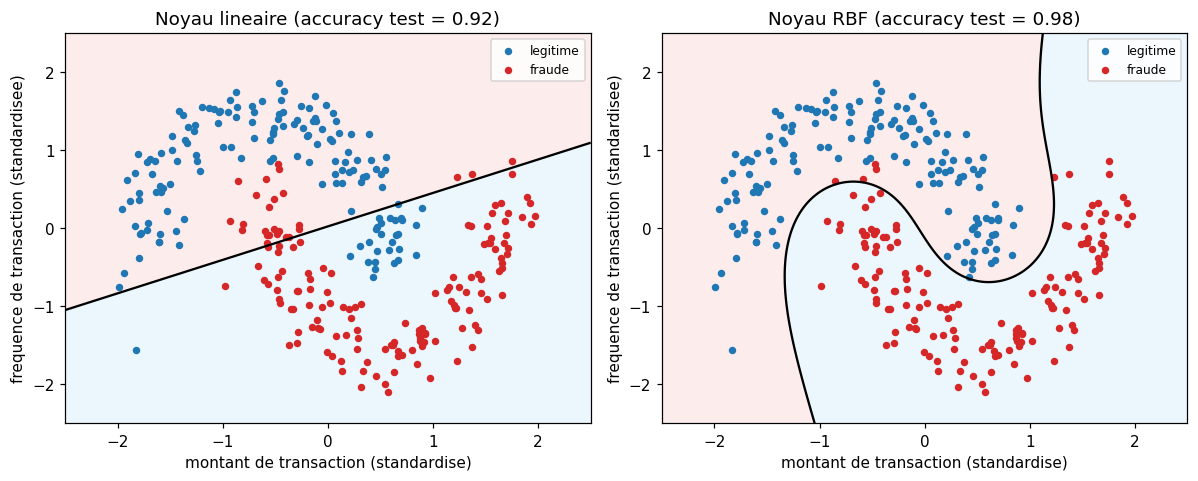

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 300), np.linspace(-2.5, 2.5, 300))
grille = np.c_[xx.ravel(), yy.ravel()]

for ax, modele, titre in zip(axes, [svm_lineaire, svm_rbf], ["Noyau lineaire", "Noyau RBF"]):
    Z = modele.decision_function(grille).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9], colors=["#fde0e0", "#e0f0fd"], alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0], colors="black", linewidths=1.5)
    ax.scatter(X_train_s[y_train == 0, 0], X_train_s[y_train == 0, 1],
               s=15, c="#1f77b4", label="legitime")
    ax.scatter(X_train_s[y_train == 1, 0], X_train_s[y_train == 1, 1],
               s=15, c="#d62728", label="fraude")
    accuracy = modele.score(X_test_s, y_test)
    ax.set_title(f"{titre} (accuracy test = {accuracy:.2f})")
    ax.set_xlabel("montant de transaction (standardise)")
    ax.set_ylabel("frequence de transaction (standardisee)")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

Le noyau linéaire trace une droite qui ne peut, par construction, épouser la forme en croissants des deux classes : une partie des transactions frauduleuses situées au-delà de cette droite est classée comme légitime. Le noyau RBF suit la frontière réelle entre les deux groupes et réduit nettement le nombre de fraudes manquées, au prix d'une frontière plus complexe et de davantage de vecteurs de support.

## 6. Effet des hyperparamètres

### 6.1 Effet de `gamma`

`gamma` contrôle la portée d'influence d'un point dans le noyau RBF. On fixe `C=1.0` et on fait varier `gamma` sur plusieurs ordres de grandeur, en mesurant l'accuracy sur l'entraînement et sur le test à chaque valeur.

In [8]:
valeurs_gamma = [0.1, 1, 10, 100]
accuracy_train_gamma, accuracy_test_gamma = [], []

for gamma in valeurs_gamma:
    modele = SVC(kernel="rbf", C=1.0, gamma=gamma).fit(X_train_s, y_train)
    accuracy_train_gamma.append(modele.score(X_train_s, y_train))
    accuracy_test_gamma.append(modele.score(X_test_s, y_test))
    print(f"gamma={gamma:6.1f} | train={accuracy_train_gamma[-1]:.3f} | test={accuracy_test_gamma[-1]:.3f}")

gamma=   0.1 | train=0.837 | test=0.940
gamma=   1.0 | train=0.993 | test=0.980
gamma=  10.0 | train=0.997 | test=0.980
gamma= 100.0 | train=1.000 | test=0.970


### 6.2 Effet de `C`

On fixe cette fois `gamma="scale"` (la valeur par défaut de scikit-learn) et on fait varier `C`, qui arbitre entre marge large et tolérance aux erreurs d'entraînement.

In [9]:
valeurs_C = [0.01, 0.1, 1, 10, 100]
accuracy_train_C, accuracy_test_C = [], []

for C in valeurs_C:
    modele = SVC(kernel="rbf", C=C, gamma="scale").fit(X_train_s, y_train)
    accuracy_train_C.append(modele.score(X_train_s, y_train))
    accuracy_test_C.append(modele.score(X_test_s, y_test))
    print(f"C={C:6.2f} | train={accuracy_train_C[-1]:.3f} | test={accuracy_test_C[-1]:.3f}")

C=  0.01 | train=0.843 | test=0.940
C=  0.10 | train=0.920 | test=0.980
C=  1.00 | train=0.987 | test=0.980
C= 10.00 | train=0.993 | test=0.980
C=100.00 | train=0.993 | test=0.960


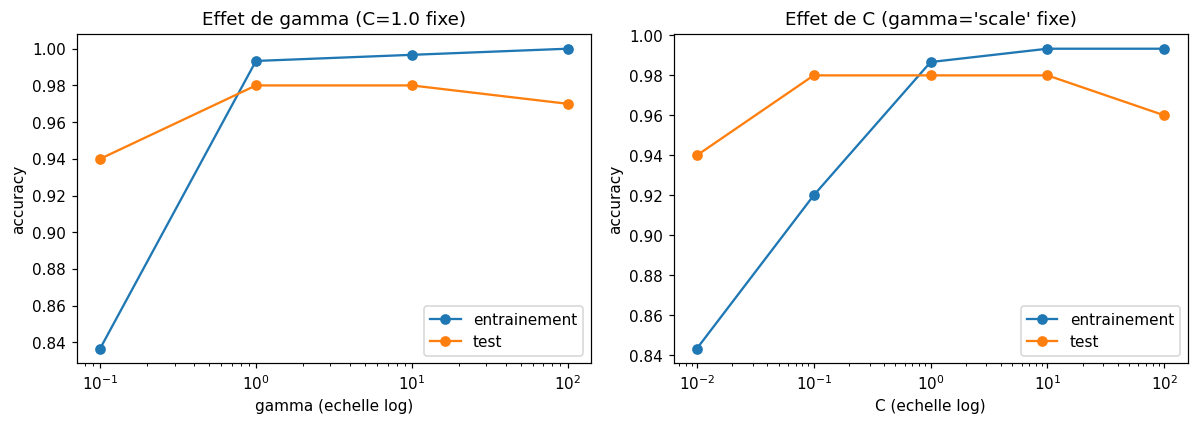

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(valeurs_gamma, accuracy_train_gamma, "o-", label="entrainement")
axes[0].plot(valeurs_gamma, accuracy_test_gamma, "o-", label="test")
axes[0].set_xscale("log")
axes[0].set_xlabel("gamma (echelle log)")
axes[0].set_ylabel("accuracy")
axes[0].set_title("Effet de gamma (C=1.0 fixe)")
axes[0].legend()

axes[1].plot(valeurs_C, accuracy_train_C, "o-", label="entrainement")
axes[1].plot(valeurs_C, accuracy_test_C, "o-", label="test")
axes[1].set_xscale("log")
axes[1].set_xlabel("C (echelle log)")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Effet de C (gamma='scale' fixe)")
axes[1].legend()

plt.tight_layout()
plt.show()

Dans les deux cas, l'accuracy d'entraînement progresse de façon monotone vers 1.0 quand `gamma` ou `C` augmente, pendant que l'accuracy de test plafonne puis redescend légèrement. C'est la signature numérique du sur-apprentissage annoncé par la théorie : au-delà d'un certain seuil, le modèle continue de mieux coller aux données d'entraînement sans que cela profite à sa capacité de généralisation. Règle pratique : partir de `gamma="scale"` et `C=1.0`, puis n'augmenter l'un ou l'autre que si l'accuracy de test progresse également — pas seulement celle d'entraînement.

## 7. Ce que la démo établit

- La résolution directe du problème d'optimisation `minimiser 0.5||w||² sous contrainte y_i(w·x_i+b)≥1` retrouve, aux erreurs numériques près, exactement le même hyperplan que `scikit-learn` sur le même jeu de points.
- Les deux points les plus proches de la frontière fixent entièrement la position de l'hyperplan ; les deux points plus éloignés n'ont aucune influence sur le résultat, conformément à la définition des vecteurs de support.
- L'identité `φ(a)·φ(b) = K(a,b)` se vérifie numériquement pour le noyau polynomial de degré 2 : le noyau donne le même résultat que la transformation explicite, sans jamais avoir besoin de la calculer.
- Sur des données non linéairement séparables, le noyau RBF réduit nettement le nombre de fraudes manquées par rapport à un noyau linéaire, au prix d'une frontière plus complexe et de davantage de vecteurs de support.
- `gamma` et `C` produisent tous deux le même type de sur-apprentissage au-delà d'un certain seuil : l'accuracy d'entraînement continue de progresser pendant que l'accuracy de test stagne ou redescend.
- Cette démo repose sur un jeu de données synthétique à deux variables ; sur un cas réel à plus haute dimension, la même méthodologie s'applique, mais la visualisation directe de la frontière de décision n'est plus possible au-delà de deux ou trois variables.

## 8. Pour aller plus loin

- Cortes, C. et Vapnik, V. (1995), *Support-Vector Networks*, Machine Learning, 20(3), 273–297 — l'article fondateur du SVM à marge souple.
- Documentation officielle scikit-learn sur `SVC` et le choix des noyaux : https://scikit-learn.org/stable/modules/svm.html
- Notes de cours CS229 (Stanford, Andrew Ng) sur les SVM et la dualité de Lagrange : https://cs229.stanford.edu/notes2022fall/main_notes.pdf
- Documentation `scipy.optimize.minimize` (méthode SLSQP), utilisée dans la section 3 : https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html
- Documentation `sklearn.datasets.make_moons`, utilisée pour générer le jeu de données de la section 1 : https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html